In [1]:
#Fitting wCDM with reduced noise
from scipy.stats import chi2
from scipy.special import erfcinv
from scipy.special import erfinv
import scipy.stats as stats
from scipy import optimize
from scipy.stats import spearmanr
from scipy.stats import ks_2samp
from scipy.stats import chi2_contingency
from scipy.integrate import quad
from scipy.optimize import curve_fit
from scipy.stats import norm

import numpy as np

from astropy.io import fits
from astropy.cosmology import w0waCDM
from astropy.cosmology import FlatLambdaCDM
from astropy.cosmology import wCDM

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.lines as mlines

import statistics as stat

import pandas as pd

import nautilus.sampler as ns
from nautilus import Prior
from nautilus import Sampler

import camb
from camb import model, initialpower
from camb.baseconfig import CAMBError

import corner
from corner import quantile
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

print("Hello world")

import h5py

ns.h5py = h5py

Hello world


In [2]:
#Check all dependencies
import numpy, scipy, matplotlib, pandas, astropy, sklearn, h5py, camb, corner, anesthetic, nautilus

print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("matplotlib:", matplotlib.__version__)
print("pandas:", pandas.__version__)
print("astropy:", astropy.__version__)
print("sklearn:", sklearn.__version__)
print("h5py:", h5py.__version__)
print("camb:", camb.__version__)
print("corner:", corner.__version__)
print("anesthetic:", anesthetic.__version__)
print("nautilus:", nautilus.__version__)

numpy: 2.4.0
scipy: 1.16.3
matplotlib: 3.10.8
pandas: 2.3.3
astropy: 7.2.0
sklearn: 1.7.2
h5py: 3.15.1
camb: 1.6.5
corner: 2.2.3
anesthetic: 2.11.0
nautilus: 1.0.5


In [3]:
#Reading the real data CSV file
df = pd.read_csv(
    'DES-Dovekie_HD.csv',
    comment='#',
    sep=r'\s+',
    engine='python'
)

In [4]:
#Selecting only the DES, CFA3, CFA4, CSP and Foundation Sne with zHD>=0.025 and a Probability of being SN1a above 0.9
allowed = [10, 63, 64, 65, 66, 150]

filtered = df[
    (df["IDSURVEY"].isin(allowed)) &
    (df["zHD"] >= 0.025) &
    (df["PROBIA_BEAMS"] > 0.9)
]

filtered.to_csv("filtered_supernova.csv", index=False)

In [5]:
#Reading the new resulting dataset
sn_real = pd.read_csv(
    'filtered_supernova.csv',
    engine='python'
)

len(sn_real)

1687

In [6]:
#Making an array with only the redshift and only the muerr
real_z = np.zeros(len(sn_real))
for i in range(len(sn_real)):
    real_z[i] = sn_real.iloc[i, 3]

real_muerr = np.zeros(len(sn_real))
for i in range(len(sn_real)):
    real_muerr[i] = sn_real.iloc[i, 6]

#Isolating the MU so we can compare later on with our synthetic data
real_mu = np.zeros(len(sn_real))
for i in range(len(sn_real)):
    real_mu[i] = sn_real.iloc[i, 5]
    
real_zHEL = np.zeros(len(sn_real))
for i in range(len(sn_real)):
    real_zHEL[i] = sn_real.iloc[i, 4]

In [7]:
#Functions to calculate likelihoods
def CMB_log_likelihood(CMB_model, CMB, inv_cov):
    delta = np.array([CMB_model - CMB])
    deltaT = np.transpose(delta)
    chi2 = np.sum(delta @ inv_cov @ deltaT)
    return -0.5*chi2

def BAO_log_likelihood(BAO_model, BAO, inv_cov):
    delta = np.array([BAO_model - BAO])
    deltaT = np.transpose(delta)
    chi2 = np.sum(delta @ inv_cov @ deltaT)
    return -0.5*chi2

def cov_log_likelihood(mu_model, mu, inv_cov):
    delta = np.array(mu_model) - np.array(mu)
    deltaT = np.transpose(delta)
    chit2 = np.sum(delta @ inv_cov @ deltaT)
    B = np.sum(delta @ inv_cov)
    C = np.sum(inv_cov)
    chi2 = chit2 - (B**2 / C) + np.log(C / (2 * np.pi))
    return -0.5*chi2

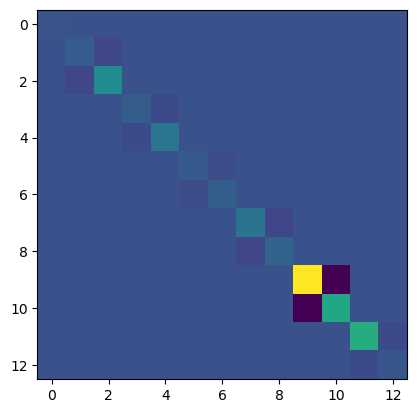

In [8]:
#Covarience matrix for BAO and CMB

corr_CMB1 = [[1, 0.46, -0.66],[0.46, 1, -0.33],[-0.66, -0.33, 1]]
corr_CMB = np.array(corr_CMB1)

sigmas = np.array([0.0046, 0.0895, 0.00015])

cov_CMB = np.diag(sigmas) @ corr_CMB @ np.diag(sigmas)

# Inverse covariance (precision matrix)
inv_CMB = np.linalg.inv(cov_CMB)

#BAO cov

zeff = np.array([0.295, 0.510, 0.706, 0.934, 1.321, 1.484, 2.330])
BAO_errors1 = [0.075, 0.167, 0.425, 0.177, 0.330, 0.152, 0.193, 0.318, 0.221, 0.760, 0.516, 0.531, 0.101]
#Reduce the errors by 40%
BAO_errors = []
for i in range(len(BAO_errors1)):
    BAO_errors.append(BAO_errors1[i]*0.6)

BAO_sd = []

for i in range(len(BAO_errors)):
    BAO_sd.append(BAO_errors[i]**2)

BAO_cov = np.diag(BAO_sd)
BAO_corr = [-0.459, -0.404, -0.416, -0.434, -0.500, -0.431]

for i, rho in enumerate(BAO_corr):
    dm_idx = 2*i + 1
    dh_idx = 2*i + 2

    cov = rho * BAO_errors[dm_idx] * BAO_errors[dh_idx]
    BAO_cov[dm_idx, dh_idx] = cov
    BAO_cov[dh_idx, dm_idx] = cov
    
inv_BAO = np.linalg.inv(BAO_cov)

plt.imshow(BAO_cov)

cng = np.random.default_rng()
bng = np.random.default_rng()
rng = np.random.default_rng()

In [9]:
def MU(z, zHEL):
    result = 5 * np.log10((1 + zHEL)* results.comoving_radial_distance(z)) + 25
    return result

In [10]:
#All likelyhoods and priors

def likelyhoodSN_w0waCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    wa=theta['wa']
    omb=theta['omb']
    H0=theta['H0']
    
    #Enforcing w0+wa<0, any time this combination occurs, likelyhood returned is -infinity

    if w0 + wa >= 0:
        return -np.inf
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
        
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        wa=wa,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)

        test_mu = []
        for i in range(1500):
            test_mu.append(MU(synth_z[i],synth_zHEL[i]))

        return cov_log_likelihood(test_mu, synth_mu, inv_SN)

    except CAMBError:
        return -np.inf
    
#BAO likelyhood:
def likelyhoodBAO_w0waCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    wa=theta['wa']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    if w0 + wa >= 0:
        return -np.inf
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        wa=wa,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        
        r_d = results.get_derived_params()['rdrag']
        H = results.hubble_parameter(zeff)
        Dm = (1 + zeff) * results.angular_diameter_distance(zeff)
        Dm_rd = Dm /r_d
        Dh = c/H
        Dh_rd = Dh/r_d
        
        BAO_test = np.zeros(13)
        
        BAO_test[0] = (zeff[0]*(Dm[0]**2)*Dh[0])**(1/3)/r_d
        BAO_test[1] = Dm_rd[1]
        BAO_test[2] = Dh_rd[1]
        BAO_test[3] = Dm_rd[2]
        BAO_test[4] = Dh_rd[2]
        BAO_test[5] = Dm_rd[3]
        BAO_test[6] = Dh_rd[3]
        BAO_test[7] = Dm_rd[4]
        BAO_test[8] = Dh_rd[4]
        BAO_test[9] = Dm_rd[5]
        BAO_test[10] = Dh_rd[5]
        BAO_test[11] = Dm_rd[6]
        BAO_test[12] = Dh_rd[6]

        return BAO_log_likelihood(BAO_test, BAO_synth, inv_BAO)
    
    except CAMBError:
        return -np.inf
    
def likelyhoodCMB_w0waCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    wa=theta['wa']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    if w0 + wa >= 0:
        return -np.inf
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        wa=wa,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        CMB_test = np.zeros(3)

        g_1 = (0.0783 * (ombh2 ** -0.238))/(1.0 + 39.5 * (ombh2 ** 0.763))
        g_2 = 0.560/(1.0 + 21.1 * (ombh2 ** 1.81))
        zstar = 1048.0 *(1.0 +0.00124 * (ombh2 ** -0.738)) *(1.0 + g_1 * (ommh2 ** g_2))

        #Calculate R
        CMB_test[0] = ((1+zstar) * results.angular_diameter_distance(zstar)*np.sqrt(Om0 * (H0**2)))/c
        #Calculate la
        CMB_test[1] = ((1+zstar) * np.pi * results.angular_diameter_distance(zstar))/results.sound_horizon(zstar)
        #Input ombh2
        CMB_test[2] = ombh2

        return CMB_log_likelihood(CMB_test, CMB_synth, inv_CMB)
    
    except CAMBError:
        return -np.inf
    
#######################################
    
def likelyhoodSN_wCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
        
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)

        test_mu = []
        for i in range(1500):
            test_mu.append(MU(synth_z[i],synth_zHEL[i]))

        return cov_log_likelihood(test_mu, synth_mu, inv_SN)
    
    except CAMBError:
        return -np.inf


def likelyhoodBAO_wCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        
        r_d = results.get_derived_params()['rdrag']
        H = results.hubble_parameter(zeff)
        Dm = (1 + zeff) * results.angular_diameter_distance(zeff)
        Dm_rd = Dm /r_d
        Dh = c/H
        Dh_rd = Dh/r_d
        
        BAO_test = np.zeros(13)
        
        BAO_test[0] = (zeff[0]*(Dm[0]**2)*Dh[0])**(1/3)/r_d
        BAO_test[1] = Dm_rd[1]
        BAO_test[2] = Dh_rd[1]
        BAO_test[3] = Dm_rd[2]
        BAO_test[4] = Dh_rd[2]
        BAO_test[5] = Dm_rd[3]
        BAO_test[6] = Dh_rd[3]
        BAO_test[7] = Dm_rd[4]
        BAO_test[8] = Dh_rd[4]
        BAO_test[9] = Dm_rd[5]
        BAO_test[10] = Dh_rd[5]
        BAO_test[11] = Dm_rd[6]
        BAO_test[12] = Dh_rd[6]

        return BAO_log_likelihood(BAO_test, BAO_synth, inv_BAO)
    
    except CAMBError:
        return -np.inf

def likelyhoodCMB_wCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        CMB_test = np.zeros(3)

        g_1 = (0.0783 * (ombh2 ** -0.238))/(1.0 + 39.5 * (ombh2 ** 0.763))
        g_2 = 0.560/(1.0 + 21.1 * (ombh2 ** 1.81))
        zstar = 1048.0 *(1.0 +0.00124 * (ombh2 ** -0.738)) *(1.0 + g_1 * (ommh2 ** g_2))

        #Calculate R
        CMB_test[0] = ((1+zstar) * results.angular_diameter_distance(zstar)*np.sqrt(Om0 * (H0**2)))/c
        #Calculate la
        CMB_test[1] = ((1+zstar) * np.pi * results.angular_diameter_distance(zstar))/results.sound_horizon(zstar)
        #Input ombh2
        CMB_test[2] = ombh2

        return CMB_log_likelihood(CMB_test, CMB_synth, inv_CMB)
    
    except CAMBError:
        return -np.inf
    
#######################################
    
def likelyhoodSN_LCDM(theta):
    Om0 = theta['Om0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
        
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=-1,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)

        test_mu = []
        for i in range(1500):
            test_mu.append(MU(synth_z[i],synth_zHEL[i]))

        return cov_log_likelihood(test_mu, synth_mu, inv_SN)
    
    except CAMBError:
        return -np.inf
    
def likelyhoodBAO_LCDM(theta):
    Om0 = theta['Om0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=-1,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        
        r_d = results.get_derived_params()['rdrag']
        H = results.hubble_parameter(zeff)
        Dm = (1 + zeff) * results.angular_diameter_distance(zeff)
        Dm_rd = Dm /r_d
        Dh = c/H
        Dh_rd = Dh/r_d
        
        BAO_test = np.zeros(13)
        
        BAO_test[0] = (zeff[0]*(Dm[0]**2)*Dh[0])**(1/3)/r_d
        BAO_test[1] = Dm_rd[1]
        BAO_test[2] = Dh_rd[1]
        BAO_test[3] = Dm_rd[2]
        BAO_test[4] = Dh_rd[2]
        BAO_test[5] = Dm_rd[3]
        BAO_test[6] = Dh_rd[3]
        BAO_test[7] = Dm_rd[4]
        BAO_test[8] = Dh_rd[4]
        BAO_test[9] = Dm_rd[5]
        BAO_test[10] = Dh_rd[5]
        BAO_test[11] = Dm_rd[6]
        BAO_test[12] = Dh_rd[6]

        return BAO_log_likelihood(BAO_test, BAO_synth, inv_BAO)
    
    except CAMBError:
        return -np.inf
    
def likelyhoodCMB_LCDM(theta):
    Om0 = theta['Om0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=-1,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        CMB_test = np.zeros(3)

        g_1 = (0.0783 * (ombh2 ** -0.238))/(1.0 + 39.5 * (ombh2 ** 0.763))
        g_2 = 0.560/(1.0 + 21.1 * (ombh2 ** 1.81))
        zstar = 1048.0 *(1.0 +0.00124 * (ombh2 ** -0.738)) *(1.0 + g_1 * (ommh2 ** g_2))

        #Calculate R
        CMB_test[0] = ((1+zstar) * results.angular_diameter_distance(zstar)*np.sqrt(Om0 * (H0**2)))/c
        #Calculate la
        CMB_test[1] = ((1+zstar) * np.pi * results.angular_diameter_distance(zstar))/results.sound_horizon(zstar)
        #Input ombh2
        CMB_test[2] = ombh2

        return CMB_log_likelihood(CMB_test, CMB_synth, inv_CMB)
    
    except CAMBError:
        return -np.inf
    
#####################################################################################################################
    
#Priors for the parameter estimation

#w0waCDM
prior_w0waCDM_est = Prior()
prior_w0waCDM_est.add_parameter('omb', dist=(0.03,0.07))
prior_w0waCDM_est.add_parameter('Om0', dist=(+0.1, +0.5))
prior_w0waCDM_est.add_parameter('wa', dist=(-3,+2))
prior_w0waCDM_est.add_parameter('w0', dist=(-3, -0.4))
prior_w0waCDM_est.add_parameter('H0', dist=(+55, +91))

#wCDM
prior_wCDM_est = Prior()
prior_wCDM_est.add_parameter('omb', dist=(0.03,0.07))
prior_wCDM_est.add_parameter('Om0', dist=(+0.1, +0.5))
prior_wCDM_est.add_parameter('w0', dist=(-3,-0.4))
prior_wCDM_est.add_parameter('H0', dist=(+55, +91))

#LCDM
prior_LCDM_est = Prior()
prior_LCDM_est.add_parameter('omb', dist=(0.03,0.07))
prior_LCDM_est.add_parameter('Om0', dist=(+0.1, +0.5))
prior_LCDM_est.add_parameter('H0', dist=(+55, +91))

#####################################################################################################################

#Likelihoods when combining probes

def likelyhoodSN_CMB_w0waCDM(theta):
    return likelyhoodSN_w0waCDM(theta) + likelyhoodCMB_w0waCDM(theta)

def likelyhoodSN_CMB_BAO_w0waCDM(theta):
    return likelyhoodSN_w0waCDM(theta) + likelyhoodCMB_w0waCDM(theta) + likelyhoodBAO_w0waCDM(theta)

def likelyhoodSN_BAO_w0waCDM(theta):
    return likelyhoodSN_w0waCDM(theta) + likelyhoodBAO_w0waCDM(theta)

#######################################

def likelyhoodSN_CMB_wCDM(theta):
    return likelyhoodSN_wCDM(theta) + likelyhoodCMB_wCDM(theta)

def likelyhoodSN_CMB_BAO_wCDM(theta):
    return likelyhoodSN_wCDM(theta) + likelyhoodCMB_wCDM(theta) + likelyhoodBAO_wCDM(theta)

def likelyhoodSN_BAO_wCDM(theta):
    return likelyhoodSN_wCDM(theta) + likelyhoodBAO_wCDM(theta)

#######################################

def likelyhoodSN_CMB_LCDM(theta):
    return likelyhoodSN_LCDM(theta) + likelyhoodCMB_LCDM(theta)

def likelyhoodSN_CMB_BAO_LCDM(theta):
    return likelyhoodSN_LCDM(theta) + likelyhoodCMB_LCDM(theta) + likelyhoodBAO_LCDM(theta)

def likelyhoodSN_BAO_LCDM(theta):
    return likelyhoodSN_LCDM(theta) + likelyhoodBAO_LCDM(theta)

In [11]:
#50 Realisations of wCDM mock data with w0waCDM, wCDM and LCDM models fit.

ombh2 = 0.02236
omch2 = 0.1202
H0 = 68.02
zstar = 1089.95
rstar = 144.39
zdrag = 1059.93
rdrag = 147.05
w = -0.995
Om0 = 0.305
c = 299792.458

#Arrays to store best fit parameters in each realisation

#w0waCDM
W0 = np.zeros(50)
W0err = np.zeros((50,2))
WA = np.zeros(50)
WAerr = np.zeros((50,2))
HUBwaw0 = np.zeros(50)
HUBwaw0err = np.zeros((50,2))
Om0waw0 = np.zeros(50)
Om0waw0err = np.zeros((50,2))
ombwaw0 = np.zeros(50)

#wCDM
W = np.zeros(50)
Werr = np.zeros((50,2))
HUBw = np.zeros(50)
HUBwerr = np.zeros((50,2))
Om0w = np.zeros(50)
Om0werr = np.zeros((50,2))
ombw = np.zeros(50)

#LCDM
HUBL = np.zeros(50)
HUBLerr = np.zeros((50,2))
Om0L = np.zeros(50)
Om0Lerr = np.zeros((50,2))
ombL = np.zeros(50)

#Storing evidences for each model each realisation
ev_w0wa = np.zeros(50)
ev_w = np.zeros(50)
ev_L = np.zeros(50)

#Coverage for 0, 20, 40, 60, 80, 100 regions for each parameter
pipeline_checkw0 = np.zeros(6)
pipeline_checkOm0 = np.zeros(6)
pipeline_checkH = np.zeros(6)

for u in range(50):
    
    # Randomly sample 1500 unique entries
    idx = np.random.choice(sn_real.shape[0], size=1500, replace=True)
    random_sn = sn_real.iloc[idx]

    synth_z = np.zeros(len(random_sn))
    synth_zHEL = np.zeros(len(random_sn))
    
    #Randomly select 1500 redshifts
    for i in range(len(random_sn)):
        synth_z[i] = random_sn.iloc[i, 3]
        synth_zHEL[i] = random_sn.iloc[i, 4]

    #Corresponding distance modulus and error
    real_mu_corresponding_to_z = np.zeros(len(random_sn))
    for i in range(len(random_sn)):
        real_mu_corresponding_to_z[i] = random_sn.iloc[i, 5]
    
    #Errors divided by 10
    real_muerr_corresponding_to_z = np.zeros(len(random_sn))
    for i in range(len(random_sn)):
        real_muerr_corresponding_to_z[i] = random_sn.iloc[i, 6] / 10
    
    #Make diagonal SN covmat with random errors
    SN_sd = []

    for z in range(len(real_muerr_corresponding_to_z)):
        SN_sd.append(real_muerr_corresponding_to_z[z]**2)

    SN_cov = np.diag(SN_sd)

    inv_SN = np.linalg.inv(SN_cov)
        
    #Producing synthetic CMB data

    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0,
        ombh2=ombh2,
        omch2=omch2,
        omk=0)

    pars.set_dark_energy(
    w=w,
    dark_energy_model='ppf'
    )

    h = H0 / 100.0
    Om0 = (ombh2 + omch2) / h**2
    ommh2 = ombh2 + omch2

    results = camb.get_background(pars)
    CMB_theory = np.zeros(3)

    g_1 = (0.0783 * (ombh2 ** -0.238))/(1.0 + 39.5 * (ombh2 ** 0.763))
    g_2 = 0.560/(1.0 + 21.1 * (ombh2 ** 1.81))
    zstar = 1048.0 *(1.0 +0.00124 * (ombh2 ** -0.738)) *(1.0 + g_1 * (ommh2 ** g_2))

    #Calculate R
    CMB_theory[0] = ((1+zstar) * results.angular_diameter_distance(zstar)*np.sqrt(Om0 * (H0**2)))/c
    #Calculate la
    CMB_theory[1] = ((1+zstar) * np.pi * results.angular_diameter_distance(zstar))/results.sound_horizon(zstar)
    #Input ombh2
    CMB_theory[2] = ombh2

    noise_CMB = cng.multivariate_normal(mean=np.zeros(3), cov=cov_CMB)
    
    #Add noise to each point

    CMB_synth = CMB_theory + noise_CMB

    #Now BAO

    r_d = results.get_derived_params()['rdrag']
    H = results.hubble_parameter(zeff)
    Dm = (1 + zeff) * results.angular_diameter_distance(zeff)
    Dm_rd = Dm /r_d
    Dh = c/H
    Dh_rd = Dh/r_d

    BAO_theory = np.zeros(13)

    BAO_theory[0] = (zeff[0]*(Dm[0]**2)*Dh[0])**(1/3)/r_d
    BAO_theory[1] = Dm_rd[1]
    BAO_theory[2] = Dh_rd[1]
    BAO_theory[3] = Dm_rd[2]
    BAO_theory[4] = Dh_rd[2]
    BAO_theory[5] = Dm_rd[3]
    BAO_theory[6] = Dh_rd[3]
    BAO_theory[7] = Dm_rd[4]
    BAO_theory[8] = Dh_rd[4]
    BAO_theory[9] = Dm_rd[5]
    BAO_theory[10] = Dh_rd[5]
    BAO_theory[11] = Dm_rd[6]
    BAO_theory[12] = Dh_rd[6]

    noise_BAO = bng.multivariate_normal(mean=np.zeros(13), cov=BAO_cov)

    #Add noise to each point
    
    BAO_synth = BAO_theory + noise_BAO

    #Now SN with noise again added to each point

    synth_mu = []
    for i in range(1500):
        synth_mu.append(MU(synth_z[i],synth_zHEL[i]) + rng.normal(loc=0.0, scale=real_muerr_corresponding_to_z[i], size=None))
        
    #run samplers to fit w0waCDM, wCDM and LCDM
    
    samplerSN_CMB_BAO_w0waCDM_est = Sampler(prior_w0waCDM_est, likelyhoodSN_CMB_BAO_w0waCDM, n_live=1000, filepath = f"2correct__Nooisyw_w0wa/{u}.h5")
    samplerSN_CMB_BAO_w0waCDM_est.run(verbose=True)
    
    samplerSN_CMB_BAO_wCDM_est = Sampler(prior_wCDM_est, likelyhoodSN_CMB_BAO_wCDM, n_live=1000, filepath = f"2correct__Nooisyw_w/{u}.h5")
    samplerSN_CMB_BAO_wCDM_est.run(verbose=True)
    
    samplerSN_CMB_BAO_LCDM_est = Sampler(prior_LCDM_est, likelyhoodSN_CMB_BAO_LCDM, n_live=1000, filepath = f"2correct__Nooisyw_L/{u}.h5")
    samplerSN_CMB_BAO_LCDM_est.run(verbose=True)
    
    #Extract points, log weights, and log likelihoods
    points_SN_CMB_BAO_w0waCDM_est, log_w_SN_CMB_BAO_w0waCDM_est, log_l_SN_CMB_BAO_w0waCDM_est = samplerSN_CMB_BAO_w0waCDM_est.posterior()
    points_SN_CMB_BAO_wCDM_est, log_w_SN_CMB_BAO_wCDM_est, log_l_SN_CMB_BAO_wCDM_est = samplerSN_CMB_BAO_wCDM_est.posterior()
    points_SN_CMB_BAO_LCDM_est, log_w_SN_CMB_BAO_LCDM_est, log_l_SN_CMB_BAO_LCDM_est = samplerSN_CMB_BAO_LCDM_est.posterior()

    #Exponentiate the weights, and isolate the points for each parameter
    
    #for w0waCDM
    weights_SN_CMB_BAO_w0waCDM_est = np.exp(log_w_SN_CMB_BAO_w0waCDM_est)
    w0_samples = points_SN_CMB_BAO_w0waCDM_est[:, 3]  
    wa_samples = points_SN_CMB_BAO_w0waCDM_est[:, 2] 
    Om0_samples = points_SN_CMB_BAO_w0waCDM_est[:, 1]
    H_samples = points_SN_CMB_BAO_w0waCDM_est[:, 4]
    omb_samples = points_SN_CMB_BAO_w0waCDM_est[:, 0]
    
    #for wCDM
    weights_SN_CMB_BAO_wCDM_est = np.exp(log_w_SN_CMB_BAO_wCDM_est)
    w02_samples = points_SN_CMB_BAO_wCDM_est[:, 2]
    Om02_samples = points_SN_CMB_BAO_wCDM_est[:, 1]
    H2_samples = points_SN_CMB_BAO_wCDM_est[:, 3]
    omb2_samples = points_SN_CMB_BAO_wCDM_est[:, 0]
    
    #for LCDM
    weights_SN_CMB_BAO_LCDM_est = np.exp(log_w_SN_CMB_BAO_LCDM_est)
    Om03_samples = points_SN_CMB_BAO_LCDM_est[:, 1]
    H3_samples = points_SN_CMB_BAO_LCDM_est[:, 2]
    omb3_samples = points_SN_CMB_BAO_LCDM_est[:, 0]

    #Extract the quantiles for each parameter
    #for w0waCDM
    w0wa_q16w0, w0wa_q50w0, w0wa_q8w0 = quantile(w0_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q16wa, w0wa_q50wa, w0wa_q8wa = quantile(wa_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q16Om0, w0wa_q50Om0, w0wa_q8Om0 = quantile(Om0_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q16H, w0wa_q50H, w0wa_q8H = quantile(H_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q16omb, w0wa_q50omb, w0wa_q8omb = quantile(omb_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_w0waCDM_est)
    
    #for wCDM
    #Extra quantiles for the pipeline check
    w_q10w02, w_q16w02, w_q20w02, w_q30w02, w_q40w02, w_q50w02, w_q60w02, w_q70w02, w_q80w02, w_q8w02, w_q90w02 = quantile(w02_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_wCDM_est)
    w_q10Om02, w_q16Om02, w_q20Om02, w_q30Om02, w_q40Om02, w_q50Om02, w_q60Om02, w_q70Om02, w_q80Om02, w_q8Om02, w_q90Om02 = quantile(Om02_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_wCDM_est)
    w_q10H2, w_q16H2, w_q20H2, w_q30H2, w_q40H2, w_q50H2, w_q60H2, w_q70H2, w_q80H2, w_q8H2, w_q90H2 = quantile(H2_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_wCDM_est)
    w_q10omb2, w_q16omb2, w_q20omb2, w_q30omb2, w_q40omb2, w_q50omb2, w_q60omb2, w_q70omb2, w_q80omb2, w_q8omb2, w_q90omb2 = quantile(omb2_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_wCDM_est)
    
    #for LCDM
    L_q16Om03, L_q50Om03, L_q8Om03 = quantile(Om03_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_LCDM_est)
    L_q16H3, L_q50H3, L_q8H3 = quantile(H3_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_LCDM_est)
    L_q16omb3, L_q50omb3, L_q8omb3 = quantile(omb3_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_LCDM_est)
    
    #Extract evidence for each model
    log_z_w0wa = samplerSN_CMB_BAO_w0waCDM_est.log_z
    log_z_w = samplerSN_CMB_BAO_wCDM_est.log_z
    log_z_L = samplerSN_CMB_BAO_LCDM_est.log_z
    
    #Input medians and errors into the arrays defined above for each parameter
    #for w0waCDM
    W0[u] = w0wa_q50w0
    W0err[u,0] = w0wa_q50w0 - w0wa_q16w0
    W0err[u,1] = w0wa_q8w0 - w0wa_q50w0
    WA[u] = w0wa_q50wa
    WAerr[u,0] = w0wa_q50wa - w0wa_q16wa
    WAerr[u,1] = w0wa_q8wa - w0wa_q50wa
    HUBwaw0[u] = w0wa_q50H
    HUBwaw0err[u,0] = w0wa_q50H - w0wa_q16H
    HUBwaw0err[u,1] = w0wa_q8H - w0wa_q50H
    Om0waw0[u] = w0wa_q50Om0
    Om0waw0err[u,0] = w0wa_q50Om0 - w0wa_q16Om0
    Om0waw0err[u,1] = w0wa_q8Om0 - w0wa_q50Om0
    ombwaw0[u] = w0wa_q50omb

    #for wCDM
    W[u] = w_q50w02
    Werr[u,0] = w_q50w02 - w_q16w02
    Werr[u,1] = w_q8w02 - w_q50w02
    HUBw[u] = w_q50H2
    HUBwerr[u,0] = w_q50H2 - w_q16H2
    HUBwerr[u,1] = w_q8H2 - w_q50H2
    Om0w[u] = w_q50Om02
    Om0werr[u,0] = w_q50Om02 - w_q16Om02
    Om0werr[u,1] = w_q8Om02 - w_q50Om02
    ombw[u] = w_q50omb2

    #for LCDM
    HUBL[u] = L_q50H3
    HUBLerr[u,0] = L_q50H3 - L_q16H3
    HUBLerr[u,1] = L_q8H3 - L_q50H3
    Om0L[u] = L_q50Om03
    Om0Lerr[u,0] = L_q50Om03 - L_q16Om03
    Om0Lerr[u,1] = L_q8Om03 - L_q50Om03
    ombL[u] = L_q50omb3
    
    #Input the evidences in the arrays
    ev_w0wa[u] = log_z_w0wa
    ev_w[u] = log_z_w
    ev_L[u] = log_z_L

    #Coverage test for each wCDM parameter fit to the wCDM mock data
    
    #H0 check
    
    # 20%
    if w_q40H2 < H0 < w_q60H2:
        pipeline_checkH[1] += 1
    # 40%
    if w_q30H2 < H0 < w_q70H2:
        pipeline_checkH[2] += 1
    # 60%
    if w_q20H2 < H0 < w_q80H2:
        pipeline_checkH[3] += 1
    # 80%
    if w_q10H2 < H0 < w_q90H2:
        pipeline_checkH[4] += 1
    pipeline_checkH[5] += 1
        
    #Om0 check
        
    # 20%
    if w_q40Om02 < Om0 < w_q60Om02:
        pipeline_checkOm0[1] += 1
    # 40%
    if w_q30Om02 < Om0 < w_q70Om02:
        pipeline_checkOm0[2] += 1
    # 60%
    if w_q20Om02 < Om0 < w_q80Om02:
        pipeline_checkOm0[3] += 1
    # 80%
    if w_q10Om02 < Om0 < w_q90Om02:
        pipeline_checkOm0[4] += 1
    pipeline_checkOm0[5] += 1
        
    #w0 check

    # 20%
    if w_q40w02 < w < w_q60w02:
        pipeline_checkw0[1] += 1
    # 40%
    if w_q30w02 < w < w_q70w02:
        pipeline_checkw0[2] += 1
    # 60%
    if w_q20w02 < w < w_q80w02:
        pipeline_checkw0[3] += 1
    # 80%
    if w_q10w02 < w < w_q90w02:
        pipeline_checkw0[4] += 1
    pipeline_checkw0[5] += 1

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44500    | N/A    | 10047 | -823.06  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39500    | N/A    | 10052 | -819.59  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 27     | 1        | 4        | 31600    | N/A    | 10024 | -814.90  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44700    | N/A    | 10102 | -7

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44700    | N/A    | 10040 | -807.11  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39300    | N/A    | 10007 | -803.77  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 28     | 1        | 4        | 32000    | N/A    | 10024 | -799.70  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44100    | N/A    | 10038 | -7

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44700    | N/A    | 10032 | -751.67  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39400    | N/A    | 10056 | -748.44  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 27     | 1        | 4        | 32000    | N/A    | 10024 | -746.45  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44800    | N/A    | 10012 | -7

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44700    | N/A    | 10076 | -825.64  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39400    | N/A    | 10075 | -822.12  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 28     | 1        | 4        | 32300    | N/A    | 10083 | -817.42  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44400    | N/A    | 10068 | -8

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44600    | N/A    | 10024 | -821.32  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 46     | 1        | 4        | 53400    | N/A    | 10003 | -789.43  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 28     | 1        | 4        | 32000    | N/A    | 10053 | -777.66  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44600    | N/A    | 10125 | -7

In [12]:
print(np.median(W0), np.std(W0))
print(np.median(WA), np.std(WA))
print(np.median(HUBwaw0), np.std(HUBwaw0))
print(np.median(Om0waw0), np.std(Om0waw0))

print(np.median(W), np.std(W))
print(np.median(HUBw), np.std(HUBw))
print(np.median(Om0w), np.std(Om0w))

print(np.median(HUBL), np.std(HUBL))
print(np.median(Om0L), np.std(Om0L))

-0.9942365357708669 0.009480478056035812
-0.0182806259136698 0.06025531063790354
68.02583091229603 0.1152269507473256
0.30894409166421605 0.0017104102279470513
-0.9967336853944109 0.00465052858724428
68.00197370996392 0.11092041162259797
0.30870928723135793 0.0014952686104655584
67.96971411557774 0.10431280796731719
0.30952600340982306 0.0008633395789355228


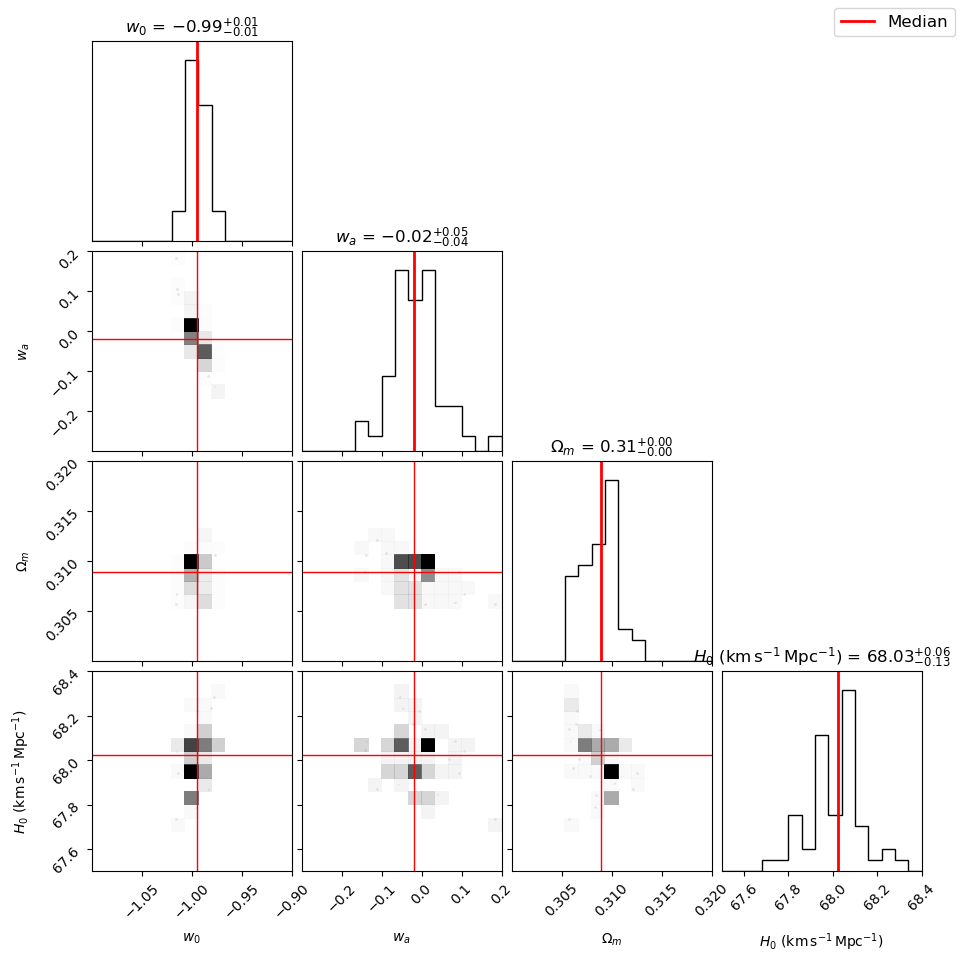

In [13]:
#Plotting points on a corner plot

samples_w0wa = np.vstack([
    W0,
    WA,
    Om0waw0,
    HUBwaw0,
]).T

# Median values
medianw0wa = [np.median(W0), np.median(WA), np.median(Om0waw0), np.median(HUBwaw0)]

# Plot ranges
ranges_w0wa = [
    (-1.1, -0.9),
    (-0.3, 0.2),
    (0.3, 0.32),
    (67.5, 68.4)
]

labels2 =[
    r"$w_0$",
    r"$w_a$",
    r"$\Omega_m$",
    r"$H_0\ \mathrm{(km\,s^{-1}\,Mpc^{-1})}$"
]

# Create corner plot
fig = corner.corner(
    samples_w0wa,
    labels=labels2,
    show_titles=True,
    range=ranges_w0wa,
    plot_datapoints=True,
    fill_contours=False,
    plot_contours=False,
    bins=15
)

# Add median lines
ndim = samples_w0wa.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(medianw0wa[i], color="red", lw=2, label="Median")

for i in range(ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axvline(medianw0wa[j], color="red", lw=1)
        ax.axhline(medianw0wa[i], color="red", lw=1)

# Add legend
median_line = mlines.Line2D([], [], color='red', lw=2, label='Median')
fig.legend(handles=[median_line], loc="upper right", fontsize=12)

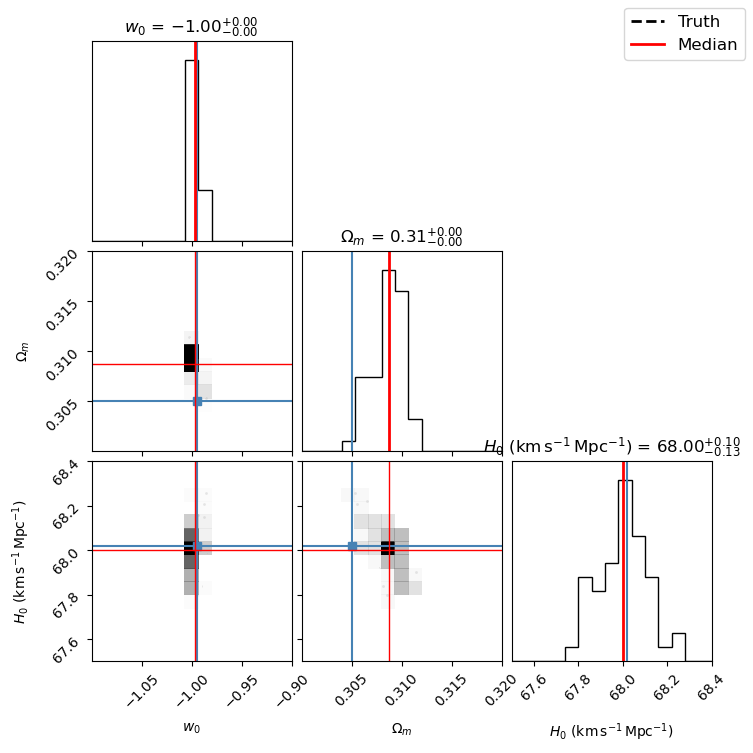

In [14]:
samples_w = np.vstack([
    W,
    Om0w,
    HUBw,
]).T

true_vals = [-0.995, 0.305, 68.02]
medianw = [np.median(W), np.median(Om0w), np.median(HUBw)]

ranges = [
    (-1.1, -0.9),
    (0.3, 0.32),
    (67.5, 68.4),
]


labels =[
    r"$w_0$",
    r"$\Omega_m$",
    r"$H_0\ \mathrm{(km\,s^{-1}\,Mpc^{-1})}$"
]

fig = corner.corner(
    samples_w,
    labels=labels,
    show_titles=True,
    truths=true_vals,
    range=ranges,
    plot_datapoints=True,
    fill_contours=False,
    plot_contours=False,
    bins=15
)

ndim = samples_w.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(medianw[i], color="red", lw=2)

for i in range(ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axvline(medianw[j], color="red", lw=1)
        ax.axhline(medianw[i], color="red", lw=1)

truth_line = mlines.Line2D([], [], color='black', lw=2, linestyle='--', label='Truth')
median_line = mlines.Line2D([], [], color='red', lw=2, label='Median')

fig.legend(handles=[truth_line, median_line], loc="upper right", fontsize=12)

In [15]:
#Tension function
def tension(mu1, cov1, mu2, cov2):
    delta = np.array(mu1) - np.array(mu2)
    cov = np.array(cov1) + np.array(cov2)
    inv_cov = np.linalg.inv(cov)
    d2 = delta.T @ inv_cov @ delta
    dof = len(delta)
    PTE = chi2.sf(d2, dof)
    print("d2:", d2)
    print("PTE:", PTE)
    return np.sqrt(2) * erfinv(1 - PTE)

In [16]:
#Calculating mean preferences
preference_w0waCDM_over_wCDM = ev_w0wa - ev_w

preference_w0waCDM_over_LCDM = ev_w0wa - ev_L

print(np.mean(preference_w0waCDM_over_LCDM))
print(np.mean(preference_w0waCDM_over_wCDM))

-8.255120111564588
-3.472340914307847


Text(0, 0.5, 'Observed Coverage Fraction')

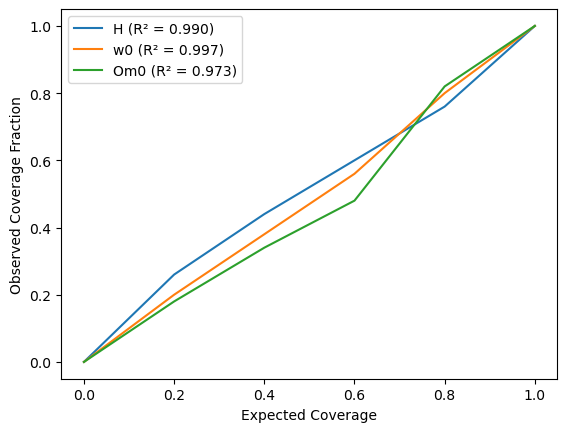

In [17]:
#coverage test graph

confidence_regions = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

H_obs = pipeline_checkH/50
w0_obs = pipeline_checkw0/50
Om0_obs = pipeline_checkOm0/50

r2_H = r2_score(confidence_regions, H_obs)
r2_w0 = r2_score(confidence_regions, w0_obs)
r2_Om0 = r2_score(confidence_regions, Om0_obs)

plt.plot(confidence_regions, H_obs, label=f"H (R² = {r2_H:.3f})")
plt.plot(confidence_regions, w0_obs, label=f"w0 (R² = {r2_w0:.3f})")
plt.plot(confidence_regions, Om0_obs, label=f"Om0 (R² = {r2_Om0:.3f})")

plt.legend()
plt.xlabel("Expected Coverage")
plt.ylabel("Observed Coverage Fraction")

In [18]:
#Running the w0waCDM mock data loop in here too to calculate tensions from the sample covariances
#If w0wCDM realisations were already run inside the w0waCDM_lessNOISE notebook, just set the path to those files when the sampler is run
#The 50 realisations are split into chuncks of 27, 8 and 15 because the kernel died a couple times.
ombh2 = 0.02236
omch2 = 0.1202
H0 = 67.47
rstar = 144.39
zdrag = 1059.93
rdrag = 147.05
w = -0.803
wa = -0.72
c = 299792.458

W01 = np.zeros(27)
W0err1 = np.zeros((27,2))
WA1 = np.zeros(27)
WAerr1 = np.zeros((27,2))
HUBwaw01 = np.zeros(27)
HUBwaw0err1 = np.zeros((27,2))
Om0waw01 = np.zeros(27)
Om0waw0err1 = np.zeros((27,2))
ombwaw01 = np.zeros(27)

W1 = np.zeros(27)
Werr1 = np.zeros((27,2))
HUBw1 = np.zeros(27)
HUBwerr1 = np.zeros((27,2))
Om0w1 = np.zeros(27)
Om0werr1 = np.zeros((27,2))
ombw1 = np.zeros(27)

HUBL1 = np.zeros(27)
HUBLerr1 = np.zeros((27,2))
Om0L1 = np.zeros(27)
Om0Lerr1 = np.zeros((27,2))
ombL1 = np.zeros(27)


for u in range(27):

    idx = np.random.choice(sn_real.shape[0], size=1500, replace=True)
    random_sn = sn_real.iloc[idx]

    synth_z = np.zeros(len(random_sn))
    synth_zHEL = np.zeros(len(random_sn))
    for i in range(len(random_sn)):
        synth_z[i] = random_sn.iloc[i, 3]
        synth_zHEL[i] = random_sn.iloc[i, 4]

    real_mu_corresponding_to_z = np.zeros(len(random_sn))
    for i in range(len(random_sn)):
        real_mu_corresponding_to_z[i] = random_sn.iloc[i, 5]

    real_muerr_corresponding_to_z = np.zeros(len(random_sn))
    for i in range(len(random_sn)):
        real_muerr_corresponding_to_z[i] = random_sn.iloc[i, 6] / 10
        
    SN_sd = []

    for z in range(len(real_muerr_corresponding_to_z)):
        SN_sd.append(real_muerr_corresponding_to_z[z]**2)

    SN_cov = np.diag(SN_sd)

    inv_SN = np.linalg.inv(SN_cov)
        

    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0,
        ombh2=ombh2,
        omch2=omch2,
        omk=0)

    pars.set_dark_energy(
    w=w,
    wa=wa,
    dark_energy_model='ppf'
    )

    h = H0 / 100.0
    Om0 = (ombh2 + omch2) / h**2
    ommh2 = ombh2 + omch2

    results = camb.get_background(pars)
    CMB_theory = np.zeros(3)

    g_1 = (0.0783 * (ombh2 ** -0.238))/(1.0 + 39.5 * (ombh2 ** 0.763))
    g_2 = 0.560/(1.0 + 21.1 * (ombh2 ** 1.81))
    zstar = 1048.0 *(1.0 +0.00124 * (ombh2 ** -0.738)) *(1.0 + g_1 * (ommh2 ** g_2))

    #Calculate R
    CMB_theory[0] = ((1+zstar) * results.angular_diameter_distance(zstar)*np.sqrt(Om0 * (H0**2)))/c
    #Calculate la
    CMB_theory[1] = ((1+zstar) * np.pi * results.angular_diameter_distance(zstar))/results.sound_horizon(zstar)
    #Input ombh2
    CMB_theory[2] = ombh2

    noise_CMB = cng.multivariate_normal(mean=np.zeros(3), cov=cov_CMB)

    CMB_synth = CMB_theory + noise_CMB

    r_d = results.get_derived_params()['rdrag']
    H = results.hubble_parameter(zeff)
    Dm = (1 + zeff) * results.angular_diameter_distance(zeff)
    Dm_rd = Dm /r_d
    Dh = c/H
    Dh_rd = Dh/r_d

    BAO_theory = np.zeros(13)

    BAO_theory[0] = (zeff[0]*(Dm[0]**2)*Dh[0])**(1/3)/r_d
    BAO_theory[1] = Dm_rd[1]
    BAO_theory[2] = Dh_rd[1]
    BAO_theory[3] = Dm_rd[2]
    BAO_theory[4] = Dh_rd[2]
    BAO_theory[5] = Dm_rd[3]
    BAO_theory[6] = Dh_rd[3]
    BAO_theory[7] = Dm_rd[4]
    BAO_theory[8] = Dh_rd[4]
    BAO_theory[9] = Dm_rd[5]
    BAO_theory[10] = Dh_rd[5]
    BAO_theory[11] = Dm_rd[6]
    BAO_theory[12] = Dh_rd[6]

    noise_BAO = bng.multivariate_normal(mean=np.zeros(13), cov=BAO_cov)

    BAO_synth = BAO_theory + noise_BAO

    synth_mu = []
    for i in range(1500):
        synth_mu.append(MU(synth_z[i],synth_zHEL[i]) + rng.normal(loc=0.0, scale=real_muerr_corresponding_to_z[i], size=None))
        
    
    
    samplerSN_CMB_BAO_w0waCDM_est = Sampler(prior_w0waCDM_est, likelyhoodSN_CMB_BAO_w0waCDM, n_live=1000, filepath = f"__lessNooisyw0wa_w0wa/{u}.h5")
    samplerSN_CMB_BAO_w0waCDM_est.run(verbose=True)
    
    samplerSN_CMB_BAO_wCDM_est = Sampler(prior_wCDM_est, likelyhoodSN_CMB_BAO_wCDM, n_live=1000, filepath = f"__lessNooisyw0wa_w/{u}.h5")
    samplerSN_CMB_BAO_wCDM_est.run(verbose=True)
    
    samplerSN_CMB_BAO_LCDM_est = Sampler(prior_LCDM_est, likelyhoodSN_CMB_BAO_LCDM, n_live=1000, filepath = f"__lessNooisyw0wa_L/{u}.h5")
    samplerSN_CMB_BAO_LCDM_est.run(verbose=True)
    
    
    points_SN_CMB_BAO_w0waCDM_est, log_w_SN_CMB_BAO_w0waCDM_est, log_l_SN_CMB_BAO_w0waCDM_est = samplerSN_CMB_BAO_w0waCDM_est.posterior()
    points_SN_CMB_BAO_wCDM_est, log_w_SN_CMB_BAO_wCDM_est, log_l_SN_CMB_BAO_wCDM_est = samplerSN_CMB_BAO_wCDM_est.posterior()
    points_SN_CMB_BAO_LCDM_est, log_w_SN_CMB_BAO_LCDM_est, log_l_SN_CMB_BAO_LCDM_est = samplerSN_CMB_BAO_LCDM_est.posterior()
    
    
    weights_SN_CMB_BAO_w0waCDM_est = np.exp(log_w_SN_CMB_BAO_w0waCDM_est)
    w0_samples = points_SN_CMB_BAO_w0waCDM_est[:, 3]  
    wa_samples = points_SN_CMB_BAO_w0waCDM_est[:, 2] 
    Om0_samples = points_SN_CMB_BAO_w0waCDM_est[:, 1]
    H_samples = points_SN_CMB_BAO_w0waCDM_est[:, 4]
    omb_samples = points_SN_CMB_BAO_w0waCDM_est[:, 0]
    
    weights_SN_CMB_BAO_wCDM_est = np.exp(log_w_SN_CMB_BAO_wCDM_est)
    w02_samples = points_SN_CMB_BAO_wCDM_est[:, 2]  # index of w0
    Om02_samples = points_SN_CMB_BAO_wCDM_est[:, 1]
    H2_samples = points_SN_CMB_BAO_wCDM_est[:, 3]
    omb2_samples = points_SN_CMB_BAO_wCDM_est[:, 0]
    
    weights_SN_CMB_BAO_LCDM_est = np.exp(log_w_SN_CMB_BAO_LCDM_est)
    Om03_samples = points_SN_CMB_BAO_LCDM_est[:, 1]
    H3_samples = points_SN_CMB_BAO_LCDM_est[:, 2]
    omb3_samples = points_SN_CMB_BAO_LCDM_est[:, 0]

    
    w0wa_q10w0, w0wa_q16w0, w0wa_q20w0, w0wa_q30w0, w0wa_q40w0, w0wa_q50w0, w0wa_q60w0, w0wa_q70w0, w0wa_q80w0, w0wa_q8w0, w0wa_q90w0 = quantile(w0_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10wa, w0wa_q16wa, w0wa_q20wa, w0wa_q30wa, w0wa_q40wa, w0wa_q50wa, w0wa_q60wa, w0wa_q70wa, w0wa_q80wa, w0wa_q8wa, w0wa_q90wa = quantile(wa_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10Om0, w0wa_q16Om0, w0wa_q20Om0, w0wa_q30Om0, w0wa_q40Om0, w0wa_q50Om0, w0wa_q60Om0, w0wa_q70Om0, w0wa_q80Om0, w0wa_q8Om0, w0wa_q90Om0 = quantile(Om0_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10H, w0wa_q16H, w0wa_q20H, w0wa_q30H, w0wa_q40H, w0wa_q50H, w0wa_q60H, w0wa_q70H, w0wa_q80H, w0wa_q8H, w0wa_q90H = quantile(H_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10omb, w0wa_q16omb, w0wa_q20omb, w0wa_q30omb, w0wa_q40omb, w0wa_q50omb, w0wa_q60omb, w0wa_q70omb, w0wa_q80omb, w0wa_q8omb, w0wa_q90omb = quantile(omb_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    
    w_q16w02, w_q50w02, w_q8w02 = quantile(w02_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    w_q16Om02, w_q50Om02, w_q8Om02 = quantile(Om02_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    w_q16H2, w_q50H2, w_q8H2 = quantile(H2_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    w_q16omb2, w_q50omb2, w_q8omb2 = quantile(omb2_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    
    L_q16Om03, L_q50Om03, L_q8Om03 = quantile(Om03_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_LCDM_est)
    L_q16H3, L_q50H3, L_q8H3 = quantile(H3_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_LCDM_est)
    L_q16omb3, L_q50omb3, L_q8omb3 = quantile(omb3_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_LCDM_est)
    
    
    log_z_w0wa = samplerSN_CMB_BAO_w0waCDM_est.log_z
    log_z_w = samplerSN_CMB_BAO_wCDM_est.log_z
    log_z_L = samplerSN_CMB_BAO_LCDM_est.log_z
    
    W01[u] = w0wa_q50w0
    W0err1[u,0] = w0wa_q50w0 - w0wa_q16w0
    W0err1[u,1] = w0wa_q8w0 - w0wa_q50w0
    WA1[u] = w0wa_q50wa
    WAerr1[u,0] = w0wa_q50wa - w0wa_q16wa
    WAerr1[u,1] = w0wa_q8wa - w0wa_q50wa
    HUBwaw01[u] = w0wa_q50H
    HUBwaw0err1[u,0] = w0wa_q50H - w0wa_q16H
    HUBwaw0err1[u,1] = w0wa_q8H - w0wa_q50H
    Om0waw01[u] = w0wa_q50Om0
    Om0waw0err1[u,0] = w0wa_q50Om0 - w0wa_q16Om0
    Om0waw0err1[u,1] = w0wa_q8Om0 - w0wa_q50Om0
    ombwaw01[u] = w0wa_q50omb

    W1[u] = w_q50w02
    Werr1[u,0] = w_q50w02 - w_q16w02
    Werr1[u,1] = w_q8w02 - w_q50w02
    HUBw1[u] = w_q50H2
    HUBwerr1[u,0] = w_q50H2 - w_q16H2
    HUBwerr1[u,1] = w_q8H2 - w_q50H2
    Om0w1[u] = w_q50Om02
    Om0werr1[u,0] = w_q50Om02 - w_q16Om02
    Om0werr1[u,1] = w_q8Om02 - w_q50Om02
    ombw1[u] = w_q50omb2

    HUBL1[u] = L_q50H3
    HUBLerr1[u,0] = L_q50H3 - L_q16H3
    HUBLerr1[u,1] = L_q8H3 - L_q50H3
    Om0L1[u] = L_q50Om03
    Om0Lerr1[u,0] = L_q50Om03 - L_q16Om03
    Om0Lerr1[u,1] = L_q8Om03 - L_q50Om03
    ombL1[u] = L_q50omb3

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44900    | N/A    | 10101 | -772.23  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39700    | N/A    | 10016 | -857.77  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 28     | 1        | 4        | 31900    | N/A    | 10110 | -1031.43 
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44600    | N/A    | 10110 | -8

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44200    | N/A    | 10009 | -773.11  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39600    | N/A    | 10088 | -844.17  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 28     | 1        | 4        | 32100    | N/A    | 10033 | -1020.12 
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44600    | N/A    | 10128 | -7

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44400    | N/A    | 10051 | -767.24  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39800    | N/A    | 10086 | -863.58  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 28     | 1        | 4        | 31800    | N/A    | 10104 | -1037.38 
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44400    | N/A    | 10019 | -7

In [19]:
W021 = np.zeros(8)
W0err21 = np.zeros((8,2))
WA21 = np.zeros(8)
WAerr21 = np.zeros((8,2))
HUBwaw021 = np.zeros(8)
HUBwaw0err21 = np.zeros((8,2))
Om0waw021 = np.zeros(8)
Om0waw0err21 = np.zeros((8,2))
ombwaw021 = np.zeros(8)

W21 = np.zeros(8)
Werr21 = np.zeros((8,2))
HUBw21 = np.zeros(8)
HUBwerr21 = np.zeros((8,2))
Om0w21 = np.zeros(8)
Om0werr21 = np.zeros((8,2))
ombw21 = np.zeros(8)

HUBL21 = np.zeros(8)
HUBLerr21 = np.zeros((8,2))
Om0L21 = np.zeros(8)
Om0Lerr21 = np.zeros((8,2))
ombL21 = np.zeros(8)


for u in range(8):
    idx = np.random.choice(sn_real.shape[0], size=1500, replace=True)
    random_sn = sn_real.iloc[idx]

    synth_z = np.zeros(len(random_sn))
    synth_zHEL = np.zeros(len(random_sn))
    for i in range(len(random_sn)):
        synth_z[i] = random_sn.iloc[i, 3]
        synth_zHEL[i] = random_sn.iloc[i, 4]

    real_mu_corresponding_to_z = np.zeros(len(random_sn))
    for i in range(len(random_sn)):
        real_mu_corresponding_to_z[i] = random_sn.iloc[i, 5]

    real_muerr_corresponding_to_z = np.zeros(len(random_sn))
    for i in range(len(random_sn)):
        real_muerr_corresponding_to_z[i] = random_sn.iloc[i, 6] / 10
        
    SN_sd = []

    for z in range(len(real_muerr_corresponding_to_z)):
        SN_sd.append(real_muerr_corresponding_to_z[z]**2)

    SN_cov = np.diag(SN_sd)

    inv_SN = np.linalg.inv(SN_cov)

    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0,
        ombh2=ombh2,
        omch2=omch2,
        omk=0)

    pars.set_dark_energy(
    w=w,
    wa=wa,
    dark_energy_model='ppf'
    )

    h = H0 / 100.0
    Om0 = (ombh2 + omch2) / h**2
    ommh2 = ombh2 + omch2

    results = camb.get_background(pars)
    CMB_theory = np.zeros(3)

    g_1 = (0.0783 * (ombh2 ** -0.238))/(1.0 + 39.5 * (ombh2 ** 0.763))
    g_2 = 0.560/(1.0 + 21.1 * (ombh2 ** 1.81))
    zstar = 1048.0 *(1.0 +0.00124 * (ombh2 ** -0.738)) *(1.0 + g_1 * (ommh2 ** g_2))

    #Calculate R
    CMB_theory[0] = ((1+zstar) * results.angular_diameter_distance(zstar)*np.sqrt(Om0 * (H0**2)))/c
    #Calculate la
    CMB_theory[1] = ((1+zstar) * np.pi * results.angular_diameter_distance(zstar))/results.sound_horizon(zstar)
    #Input ombh2
    CMB_theory[2] = ombh2

    noise_CMB = cng.multivariate_normal(mean=np.zeros(3), cov=cov_CMB)

    CMB_synth = CMB_theory + noise_CMB

    r_d = results.get_derived_params()['rdrag']
    H = results.hubble_parameter(zeff)
    Dm = (1 + zeff) * results.angular_diameter_distance(zeff)
    Dm_rd = Dm /r_d
    Dh = c/H
    Dh_rd = Dh/r_d

    BAO_theory = np.zeros(13)

    BAO_theory[0] = (zeff[0]*(Dm[0]**2)*Dh[0])**(1/3)/r_d
    BAO_theory[1] = Dm_rd[1]
    BAO_theory[2] = Dh_rd[1]
    BAO_theory[3] = Dm_rd[2]
    BAO_theory[4] = Dh_rd[2]
    BAO_theory[5] = Dm_rd[3]
    BAO_theory[6] = Dh_rd[3]
    BAO_theory[7] = Dm_rd[4]
    BAO_theory[8] = Dh_rd[4]
    BAO_theory[9] = Dm_rd[5]
    BAO_theory[10] = Dh_rd[5]
    BAO_theory[11] = Dm_rd[6]
    BAO_theory[12] = Dh_rd[6]

    noise_BAO = bng.multivariate_normal(mean=np.zeros(13), cov=BAO_cov)

    BAO_synth = BAO_theory + noise_BAO

    synth_mu = []
    for i in range(1500):
        synth_mu.append(MU(synth_z[i],synth_zHEL[i]) + rng.normal(loc=0.0, scale=real_muerr_corresponding_to_z[i], size=None))
        
    
    samplerSN_CMB_BAO_w0waCDM_est = Sampler(prior_w0waCDM_est, likelyhoodSN_CMB_BAO_w0waCDM, n_live=1000, filepath = f"__2lessNooisyw0wa_w0wa/{u}.h5")
    samplerSN_CMB_BAO_w0waCDM_est.run(verbose=True)
    
    samplerSN_CMB_BAO_wCDM_est = Sampler(prior_wCDM_est, likelyhoodSN_CMB_BAO_wCDM, n_live=1000, filepath = f"__2lessNooisyw0wa_w/{u}.h5")
    samplerSN_CMB_BAO_wCDM_est.run(verbose=True)
    
    samplerSN_CMB_BAO_LCDM_est = Sampler(prior_LCDM_est, likelyhoodSN_CMB_BAO_LCDM, n_live=1000, filepath = f"__2lessNooisyw0wa_L/{u}.h5")
    samplerSN_CMB_BAO_LCDM_est.run(verbose=True)
    
    
    points_SN_CMB_BAO_w0waCDM_est, log_w_SN_CMB_BAO_w0waCDM_est, log_l_SN_CMB_BAO_w0waCDM_est = samplerSN_CMB_BAO_w0waCDM_est.posterior()
    points_SN_CMB_BAO_wCDM_est, log_w_SN_CMB_BAO_wCDM_est, log_l_SN_CMB_BAO_wCDM_est = samplerSN_CMB_BAO_wCDM_est.posterior()
    points_SN_CMB_BAO_LCDM_est, log_w_SN_CMB_BAO_LCDM_est, log_l_SN_CMB_BAO_LCDM_est = samplerSN_CMB_BAO_LCDM_est.posterior()
    
    
    weights_SN_CMB_BAO_w0waCDM_est = np.exp(log_w_SN_CMB_BAO_w0waCDM_est)
    w0_samples = points_SN_CMB_BAO_w0waCDM_est[:, 3]  
    wa_samples = points_SN_CMB_BAO_w0waCDM_est[:, 2] 
    Om0_samples = points_SN_CMB_BAO_w0waCDM_est[:, 1]
    H_samples = points_SN_CMB_BAO_w0waCDM_est[:, 4]
    omb_samples = points_SN_CMB_BAO_w0waCDM_est[:, 0]
    
    weights_SN_CMB_BAO_wCDM_est = np.exp(log_w_SN_CMB_BAO_wCDM_est)
    w02_samples = points_SN_CMB_BAO_wCDM_est[:, 2]  # index of w0
    Om02_samples = points_SN_CMB_BAO_wCDM_est[:, 1]
    H2_samples = points_SN_CMB_BAO_wCDM_est[:, 3]
    omb2_samples = points_SN_CMB_BAO_wCDM_est[:, 0]
    
    weights_SN_CMB_BAO_LCDM_est = np.exp(log_w_SN_CMB_BAO_LCDM_est)
    Om03_samples = points_SN_CMB_BAO_LCDM_est[:, 1]
    H3_samples = points_SN_CMB_BAO_LCDM_est[:, 2]
    omb3_samples = points_SN_CMB_BAO_LCDM_est[:, 0]

    
    w0wa_q10w0, w0wa_q16w0, w0wa_q20w0, w0wa_q30w0, w0wa_q40w0, w0wa_q50w0, w0wa_q60w0, w0wa_q70w0, w0wa_q80w0, w0wa_q8w0, w0wa_q90w0 = quantile(w0_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10wa, w0wa_q16wa, w0wa_q20wa, w0wa_q30wa, w0wa_q40wa, w0wa_q50wa, w0wa_q60wa, w0wa_q70wa, w0wa_q80wa, w0wa_q8wa, w0wa_q90wa = quantile(wa_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10Om0, w0wa_q16Om0, w0wa_q20Om0, w0wa_q30Om0, w0wa_q40Om0, w0wa_q50Om0, w0wa_q60Om0, w0wa_q70Om0, w0wa_q80Om0, w0wa_q8Om0, w0wa_q90Om0 = quantile(Om0_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10H, w0wa_q16H, w0wa_q20H, w0wa_q30H, w0wa_q40H, w0wa_q50H, w0wa_q60H, w0wa_q70H, w0wa_q80H, w0wa_q8H, w0wa_q90H = quantile(H_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10omb, w0wa_q16omb, w0wa_q20omb, w0wa_q30omb, w0wa_q40omb, w0wa_q50omb, w0wa_q60omb, w0wa_q70omb, w0wa_q80omb, w0wa_q8omb, w0wa_q90omb = quantile(omb_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    
    w_q16w02, w_q50w02, w_q8w02 = quantile(w02_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    w_q16Om02, w_q50Om02, w_q8Om02 = quantile(Om02_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    w_q16H2, w_q50H2, w_q8H2 = quantile(H2_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    w_q16omb2, w_q50omb2, w_q8omb2 = quantile(omb2_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    
    L_q16Om03, L_q50Om03, L_q8Om03 = quantile(Om03_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_LCDM_est)
    L_q16H3, L_q50H3, L_q8H3 = quantile(H3_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_LCDM_est)
    L_q16omb3, L_q50omb3, L_q8omb3 = quantile(omb3_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_LCDM_est)
    
    
    log_z_w0wa = samplerSN_CMB_BAO_w0waCDM_est.log_z
    log_z_w = samplerSN_CMB_BAO_wCDM_est.log_z
    log_z_L = samplerSN_CMB_BAO_LCDM_est.log_z
    
    W021[u] = w0wa_q50w0
    W0err21[u,0] = w0wa_q50w0 - w0wa_q16w0
    W0err21[u,1] = w0wa_q8w0 - w0wa_q50w0
    WA21[u] = w0wa_q50wa
    WAerr21[u,0] = w0wa_q50wa - w0wa_q16wa
    WAerr21[u,1] = w0wa_q8wa - w0wa_q50wa
    HUBwaw021[u] = w0wa_q50H
    HUBwaw0err21[u,0] = w0wa_q50H - w0wa_q16H
    HUBwaw0err21[u,1] = w0wa_q8H - w0wa_q50H
    Om0waw021[u] = w0wa_q50Om0
    Om0waw0err21[u,0] = w0wa_q50Om0 - w0wa_q16Om0
    Om0waw0err21[u,1] = w0wa_q8Om0 - w0wa_q50Om0
    ombwaw021[u] = w0wa_q50omb

    W21[u] = w_q50w02
    Werr21[u,0] = w_q50w02 - w_q16w02
    Werr21[u,1] = w_q8w02 - w_q50w02
    HUBw21[u] = w_q50H2
    HUBwerr21[u,0] = w_q50H2 - w_q16H2
    HUBwerr21[u,1] = w_q8H2 - w_q50H2
    Om0w21[u] = w_q50Om02
    Om0werr21[u,0] = w_q50Om02 - w_q16Om02
    Om0werr21[u,1] = w_q8Om02 - w_q50Om02
    ombw21[u] = w_q50omb2

    HUBL21[u] = L_q50H3
    HUBLerr21[u,0] = L_q50H3 - L_q16H3
    HUBLerr21[u,1] = L_q8H3 - L_q50H3
    Om0L21[u] = L_q50Om03
    Om0Lerr21[u,0] = L_q50Om03 - L_q16Om03
    Om0Lerr21[u,1] = L_q8Om03 - L_q50Om03
    ombL21[u] = L_q50omb3

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44400    | N/A    | 10002 | -793.62  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39600    | N/A    | 10061 | -870.32  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 27     | 1        | 4        | 31500    | N/A    | 10053 | -1030.49 
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44300    | N/A    | 10080 | -7

In [20]:
W031 = np.zeros(15)
W0err31 = np.zeros((15,2))
WA31 = np.zeros(15)
WAerr31 = np.zeros((15,2))
HUBwaw031 = np.zeros(15)
HUBwaw0err31 = np.zeros((15,2))
Om0waw031 = np.zeros(15)
Om0waw0err31 = np.zeros((15,2))
ombwaw031 = np.zeros(15)

W31 = np.zeros(15)
Werr31 = np.zeros((15,2))
HUBw31 = np.zeros(15)
HUBwerr31 = np.zeros((15,2))
Om0w31 = np.zeros(15)
Om0werr31 = np.zeros((15,2))
ombw31 = np.zeros(15)

HUBL31 = np.zeros(15)
HUBLerr31 = np.zeros((15,2))
Om0L31 = np.zeros(15)
Om0Lerr31 = np.zeros((15,2))
ombL31 = np.zeros(15)

for u in range(15):
    idx = np.random.choice(sn_real.shape[0], size=1500, replace=True)
    random_sn = sn_real.iloc[idx]

    synth_z = np.zeros(len(random_sn))
    synth_zHEL = np.zeros(len(random_sn))
    for i in range(len(random_sn)):
        synth_z[i] = random_sn.iloc[i, 3]
        synth_zHEL[i] = random_sn.iloc[i, 4]

    real_mu_corresponding_to_z = np.zeros(len(random_sn))
    for i in range(len(random_sn)):
        real_mu_corresponding_to_z[i] = random_sn.iloc[i, 5]

    real_muerr_corresponding_to_z = np.zeros(len(random_sn))
    for i in range(len(random_sn)):
        real_muerr_corresponding_to_z[i] = random_sn.iloc[i, 6] / 10
        
    SN_sd = []

    for z in range(len(real_muerr_corresponding_to_z)):
        SN_sd.append(real_muerr_corresponding_to_z[z]**2)

    SN_cov = np.diag(SN_sd)

    inv_SN = np.linalg.inv(SN_cov)

    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0,
        ombh2=ombh2,
        omch2=omch2,
        omk=0)

    pars.set_dark_energy(
    w=w,
    wa=wa,
    dark_energy_model='ppf'
    )

    h = H0 / 100.0
    Om0 = (ombh2 + omch2) / h**2
    ommh2 = ombh2 + omch2

    results = camb.get_background(pars)
    CMB_theory = np.zeros(3)

    g_1 = (0.0783 * (ombh2 ** -0.238))/(1.0 + 39.5 * (ombh2 ** 0.763))
    g_2 = 0.560/(1.0 + 21.1 * (ombh2 ** 1.81))
    zstar = 1048.0 *(1.0 +0.00124 * (ombh2 ** -0.738)) *(1.0 + g_1 * (ommh2 ** g_2))

    #Calculate R
    CMB_theory[0] = ((1+zstar) * results.angular_diameter_distance(zstar)*np.sqrt(Om0 * (H0**2)))/c
    #Calculate la
    CMB_theory[1] = ((1+zstar) * np.pi * results.angular_diameter_distance(zstar))/results.sound_horizon(zstar)
    #Input ombh2
    CMB_theory[2] = ombh2

    noise_CMB = cng.multivariate_normal(mean=np.zeros(3), cov=cov_CMB)

    CMB_synth = CMB_theory + noise_CMB

    #NOW BAO

    r_d = results.get_derived_params()['rdrag']
    H = results.hubble_parameter(zeff)
    Dm = (1 + zeff) * results.angular_diameter_distance(zeff)
    Dm_rd = Dm /r_d
    Dh = c/H
    Dh_rd = Dh/r_d

    BAO_theory = np.zeros(13)

    BAO_theory[0] = (zeff[0]*(Dm[0]**2)*Dh[0])**(1/3)/r_d
    BAO_theory[1] = Dm_rd[1]
    BAO_theory[2] = Dh_rd[1]
    BAO_theory[3] = Dm_rd[2]
    BAO_theory[4] = Dh_rd[2]
    BAO_theory[5] = Dm_rd[3]
    BAO_theory[6] = Dh_rd[3]
    BAO_theory[7] = Dm_rd[4]
    BAO_theory[8] = Dh_rd[4]
    BAO_theory[9] = Dm_rd[5]
    BAO_theory[10] = Dh_rd[5]
    BAO_theory[11] = Dm_rd[6]
    BAO_theory[12] = Dh_rd[6]

    noise_BAO = bng.multivariate_normal(mean=np.zeros(13), cov=BAO_cov)

    BAO_synth = BAO_theory + noise_BAO

    synth_mu = []
    for i in range(1500):
        synth_mu.append(MU(synth_z[i],synth_zHEL[i]) + rng.normal(loc=0.0, scale=real_muerr_corresponding_to_z[i], size=None))
        
    
    samplerSN_CMB_BAO_w0waCDM_est = Sampler(prior_w0waCDM_est, likelyhoodSN_CMB_BAO_w0waCDM, n_live=1000, filepath = f"__3lessNooisyw0wa_w0wa/{u}.h5")
    samplerSN_CMB_BAO_w0waCDM_est.run(verbose=True)
    
    samplerSN_CMB_BAO_wCDM_est = Sampler(prior_wCDM_est, likelyhoodSN_CMB_BAO_wCDM, n_live=1000, filepath = f"__3lessNooisyw0wa_w/{u}.h5")
    samplerSN_CMB_BAO_wCDM_est.run(verbose=True)
    
    samplerSN_CMB_BAO_LCDM_est = Sampler(prior_LCDM_est, likelyhoodSN_CMB_BAO_LCDM, n_live=1000, filepath = f"__3lessNooisyw0wa_L/{u}.h5")
    samplerSN_CMB_BAO_LCDM_est.run(verbose=True)
    
    
    points_SN_CMB_BAO_w0waCDM_est, log_w_SN_CMB_BAO_w0waCDM_est, log_l_SN_CMB_BAO_w0waCDM_est = samplerSN_CMB_BAO_w0waCDM_est.posterior()
    points_SN_CMB_BAO_wCDM_est, log_w_SN_CMB_BAO_wCDM_est, log_l_SN_CMB_BAO_wCDM_est = samplerSN_CMB_BAO_wCDM_est.posterior()
    points_SN_CMB_BAO_LCDM_est, log_w_SN_CMB_BAO_LCDM_est, log_l_SN_CMB_BAO_LCDM_est = samplerSN_CMB_BAO_LCDM_est.posterior()
    
    
    weights_SN_CMB_BAO_w0waCDM_est = np.exp(log_w_SN_CMB_BAO_w0waCDM_est)
    w0_samples = points_SN_CMB_BAO_w0waCDM_est[:, 3]  
    wa_samples = points_SN_CMB_BAO_w0waCDM_est[:, 2] 
    Om0_samples = points_SN_CMB_BAO_w0waCDM_est[:, 1]
    H_samples = points_SN_CMB_BAO_w0waCDM_est[:, 4]
    omb_samples = points_SN_CMB_BAO_w0waCDM_est[:, 0]
    
    weights_SN_CMB_BAO_wCDM_est = np.exp(log_w_SN_CMB_BAO_wCDM_est)
    w02_samples = points_SN_CMB_BAO_wCDM_est[:, 2]  # index of w0
    Om02_samples = points_SN_CMB_BAO_wCDM_est[:, 1]
    H2_samples = points_SN_CMB_BAO_wCDM_est[:, 3]
    omb2_samples = points_SN_CMB_BAO_wCDM_est[:, 0]
    
    weights_SN_CMB_BAO_LCDM_est = np.exp(log_w_SN_CMB_BAO_LCDM_est)
    Om03_samples = points_SN_CMB_BAO_LCDM_est[:, 1]
    H3_samples = points_SN_CMB_BAO_LCDM_est[:, 2]
    omb3_samples = points_SN_CMB_BAO_LCDM_est[:, 0]

    
    w0wa_q10w0, w0wa_q16w0, w0wa_q20w0, w0wa_q30w0, w0wa_q40w0, w0wa_q50w0, w0wa_q60w0, w0wa_q70w0, w0wa_q80w0, w0wa_q8w0, w0wa_q90w0 = quantile(w0_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10wa, w0wa_q16wa, w0wa_q20wa, w0wa_q30wa, w0wa_q40wa, w0wa_q50wa, w0wa_q60wa, w0wa_q70wa, w0wa_q80wa, w0wa_q8wa, w0wa_q90wa = quantile(wa_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10Om0, w0wa_q16Om0, w0wa_q20Om0, w0wa_q30Om0, w0wa_q40Om0, w0wa_q50Om0, w0wa_q60Om0, w0wa_q70Om0, w0wa_q80Om0, w0wa_q8Om0, w0wa_q90Om0 = quantile(Om0_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10H, w0wa_q16H, w0wa_q20H, w0wa_q30H, w0wa_q40H, w0wa_q50H, w0wa_q60H, w0wa_q70H, w0wa_q80H, w0wa_q8H, w0wa_q90H = quantile(H_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10omb, w0wa_q16omb, w0wa_q20omb, w0wa_q30omb, w0wa_q40omb, w0wa_q50omb, w0wa_q60omb, w0wa_q70omb, w0wa_q80omb, w0wa_q8omb, w0wa_q90omb = quantile(omb_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    
    w_q16w02, w_q50w02, w_q8w02 = quantile(w02_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    w_q16Om02, w_q50Om02, w_q8Om02 = quantile(Om02_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    w_q16H2, w_q50H2, w_q8H2 = quantile(H2_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    w_q16omb2, w_q50omb2, w_q8omb2 = quantile(omb2_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    
    L_q16Om03, L_q50Om03, L_q8Om03 = quantile(Om03_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_LCDM_est)
    L_q16H3, L_q50H3, L_q8H3 = quantile(H3_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_LCDM_est)
    L_q16omb3, L_q50omb3, L_q8omb3 = quantile(omb3_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_LCDM_est)
    
    
    log_z_w0wa = samplerSN_CMB_BAO_w0waCDM_est.log_z
    log_z_w = samplerSN_CMB_BAO_wCDM_est.log_z
    log_z_L = samplerSN_CMB_BAO_LCDM_est.log_z
    
    W031[u] = w0wa_q50w0
    W0err31[u,0] = w0wa_q50w0 - w0wa_q16w0
    W0err31[u,1] = w0wa_q8w0 - w0wa_q50w0
    WA31[u] = w0wa_q50wa
    WAerr31[u,0] = w0wa_q50wa - w0wa_q16wa
    WAerr31[u,1] = w0wa_q8wa - w0wa_q50wa
    HUBwaw031[u] = w0wa_q50H
    HUBwaw0err31[u,0] = w0wa_q50H - w0wa_q16H
    HUBwaw0err31[u,1] = w0wa_q8H - w0wa_q50H
    Om0waw031[u] = w0wa_q50Om0
    Om0waw0err31[u,0] = w0wa_q50Om0 - w0wa_q16Om0
    Om0waw0err31[u,1] = w0wa_q8Om0 - w0wa_q50Om0
    ombwaw031[u] = w0wa_q50omb

    W31[u] = w_q50w02
    Werr31[u,0] = w_q50w02 - w_q16w02
    Werr31[u,1] = w_q8w02 - w_q50w02
    HUBw31[u] = w_q50H2
    HUBwerr31[u,0] = w_q50H2 - w_q16H2
    HUBwerr31[u,1] = w_q8H2 - w_q50H2
    Om0w31[u] = w_q50Om02
    Om0werr31[u,0] = w_q50Om02 - w_q16Om02
    Om0werr31[u,1] = w_q8Om02 - w_q50Om02
    ombw31[u] = w_q50omb2

    HUBL31[u] = L_q50H3
    HUBLerr31[u,0] = L_q50H3 - L_q16H3
    HUBLerr31[u,1] = L_q8H3 - L_q50H3
    Om0L31[u] = L_q50Om03
    Om0Lerr31[u,0] = L_q50Om03 - L_q16Om03
    Om0Lerr31[u,1] = L_q8Om03 - L_q50Om03
    ombL31[u] = L_q50omb3

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44500    | N/A    | 10066 | -810.98  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39600    | N/A    | 10020 | -890.76  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 27     | 1        | 4        | 31900    | N/A    | 10007 | -1060.65 
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44300    | N/A    | 10072 | -7

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44600    | N/A    | 10058 | -759.61  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39600    | N/A    | 10103 | -837.33  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 27     | 1        | 4        | 32100    | N/A    | 10026 | -1035.57 
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44100    | N/A    | 10013 | -8

In [21]:
#Concatenating the arrays for the 3 realisation chuncks

W0tgt = np.concatenate((W01, W021, W031))
WAtgt = np.concatenate((WA1, WA21, WA31))
HUBwaw0tgt = np.concatenate((HUBwaw01, HUBwaw021, HUBwaw031))
Om0waw0tgt = np.concatenate((Om0waw01, Om0waw021, Om0waw031))
ombwaw0tgt = np.concatenate((ombwaw01, ombwaw021, ombwaw031))

Wtgt = np.concatenate((W1, W21, W31))
HUBwtgt = np.concatenate((HUBw1, HUBw21, HUBw31))
Om0wtgt = np.concatenate((Om0w1, Om0w21, Om0w31))
ombwtgt = np.concatenate((ombw1, ombw21, ombw31))

HUBLtgt = np.concatenate((HUBL1, HUBL21, HUBL31))
Om0Ltgt = np.concatenate((Om0L1, Om0L21, Om0L31))
ombLtgt = np.concatenate((ombL1, ombL21, ombL31))


#w0wCDM--------------------------------------
# w0waCDM parameter matrix
params_w0wa1 = np.vstack([
    ombwaw0tgt,
    W0tgt,
    WAtgt,
    HUBwaw0tgt,
    Om0waw0tgt
]).T

# wCDM parameter matrix
params_w1 = np.vstack([
    ombwtgt,
    Wtgt,
    HUBwtgt,
    Om0wtgt
]).T

# LCDM parameter matrix
params_L1 = np.vstack([
    ombLtgt,
    HUBLtgt,
    Om0Ltgt
]).T

#covariance matrices for 50 realisations
w0wa_cov_w0wa = np.cov(params_w0wa1, rowvar=False)
w0wa_cov_w = np.cov(params_w1, rowvar=False)
w0wa_cov_L = np.cov(params_L1, rowvar=False)


#wCDM-----------------------------------------
# w0waCDM parameter matrix
params_w0wa = np.vstack([
    ombwaw0,
    W0,
    WA,
    HUBwaw0,
    Om0waw0
]).T

# wCDM parameter matrix
params_w = np.vstack([
    ombw,
    W,
    HUBw,
    Om0w
]).T

# LCDM parameter matrix
params_L = np.vstack([
    ombL,
    HUBL,
    Om0L
]).T
#covariance matrices for 50 realisations
w_cov_w0wa = np.cov(params_w0wa, rowvar=False)
w_cov_w = np.cov(params_w, rowvar=False)
w_cov_L = np.cov(params_L, rowvar=False)

In [22]:
#Building the data vectors to input into the tension function

w0wadatavec_w0wa = np.array((np.median(ombwaw0tgt), np.median(W0tgt), np.median(WAtgt), np.median(HUBwaw0tgt), np.median(Om0waw0tgt)))
w0wadatavec_w = np.array((np.median(ombwtgt), np.median(Wtgt), np.median(HUBwtgt), np.median(Om0wtgt)))
w0wadatavec_L = np.array((np.median(ombLtgt), np.median(HUBLtgt), np.median(Om0Ltgt)))
                            
wdatavec_w0wa = np.array((np.median(ombwaw0), np.median(W0), np.median(WA), np.median(HUBwaw0), np.median(Om0waw0)))
wdatavec_w = np.array((np.median(ombw), np.median(W), np.median(HUBw), np.median(Om0w)))
wdatavec_L = np.array((np.median(ombL), np.median(HUBL), np.median(Om0L)))
                         
w0wa_tension = tension(w0wadatavec_w0wa, w0wa_cov_w0wa, wdatavec_w0wa, w_cov_w0wa)
w_tension = tension(w0wadatavec_w, w0wa_cov_w, wdatavec_w, w_cov_w)
L_tension = tension(w0wadatavec_L, w0wa_cov_L, wdatavec_L, w_cov_L)

print(w0wa_tension, w_tension, L_tension)
print(np.var(params_w0wa, axis=0))
print(np.diag(w_cov_w0wa))
print(np.var(params_w0wa1, axis=0))
print(np.diag(w0wa_cov_w0wa))

d2: 571.3057699170404
PTE: 3.1983690796139084e-121
d2: 411.5354190907037
PTE: 8.947504129370899e-88
d2: 184.60757276074662
PTE: 8.920176315426292e-40
inf inf inf
[4.56063136e-08 8.98794642e-05 3.63070246e-03 1.32772502e-02
 2.92550315e-06]
[4.65370547e-08 9.17137389e-05 3.70479843e-03 1.35482145e-02
 2.98520729e-06]
[4.14144276e-08 7.48473847e-05 2.85183368e-03 1.53939564e-02
 3.90979865e-06]
[4.22596200e-08 7.63748823e-05 2.91003437e-03 1.57081188e-02
 3.98959046e-06]
